# Indian Crude Oil Supply, Production & Demand Forecasting


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
cru_d = pd.read_csv(r"C:\Users\Rahul Raj\Desktop\My KARE Academics\4th year\Crude oil Import and Export Forecasting\Dataset\Crude oil import and petroleum product importexport by Oil companies (1).csv")
cru_d.head()

,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes),Value in Rupees (Crore),Value in Dollars (Million US dollar),date_updated
0,April,2024,CRUDE OIL,Import,21439.18,108423.53,12992.53,10-03-2025 04:00
1,April,2024,LPG,Import,1570.75,8005.70,959.87,10-03-2025 04:00
2,April,2024,MS,Import,29.99,224.85,26.97,10-03-2025 04:00
3,April,2024,Naphtha,Import,121.22,735.58,88.19,10-03-2025 04:00
4,April,2024,ATF,Import,0.00,0.02,0.00,10-03-2025 04:00


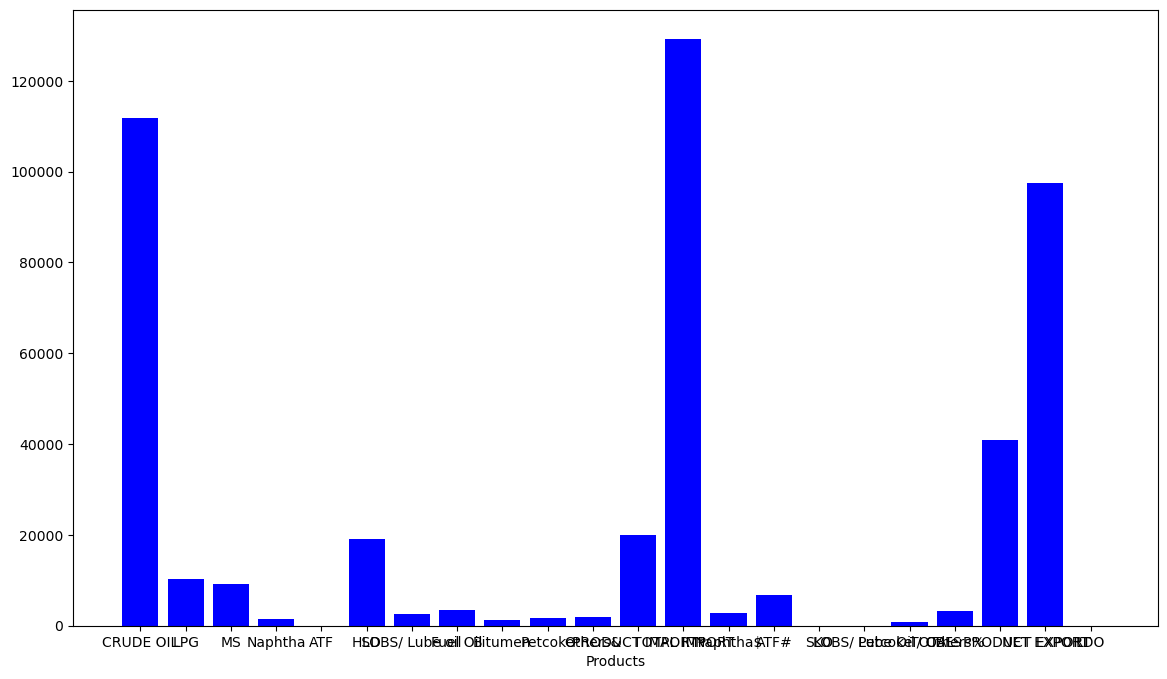

In [4]:
plt.figure(figsize=(14,8))
plt.bar(cru_d['PRODUCTS'],cru_d['Value in Rupees (Crore)'], label="Most Valuable Products", color='blue')
plt.xlabel('Products')
plt.show()

## Data Cleaning / Data Pre-Processing 

In [5]:
# Drop unnecessary columns
cru_clean = cru_d.drop(columns=["date_updated"])

# Drop rows with missing values in key numerical columns
cru_clean = cru_clean.dropna(subset=["Quantity (000 Metric Tonnes)", "Value in Rupees (Crore)", "Value in Dollars (Million US dollar)"])

# Convert Year to datetime format for better time series analysis
cru_clean["Date"] = pd.to_datetime(cru_clean["Year"].astype(str) + "-" + cru_clean["Month"], errors='coerce')

cru_clean.info(), cru_clean.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 465 entries, 0 to 505
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Month                                 465 non-null    object        
 1   Year                                  465 non-null    int64         
 2   PRODUCTS                              465 non-null    object        
 3   TRADE                                 465 non-null    object        
 4   Quantity (000 Metric Tonnes)          465 non-null    float64       
 5   Value in Rupees (Crore)               465 non-null    float64       
 6   Value in Dollars (Million US dollar)  465 non-null    float64       
 7   Date                                  465 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 32.7+ KB


(None,
    Month  Year   PRODUCTS   TRADE  Quantity (000 Metric Tonnes)  \
 0  April  2024  CRUDE OIL  Import                      21439.18   
 1  April  2024        LPG  Import                       1570.75   
 2  April  2024         MS  Import                         29.99   
 3  April  2024    Naphtha  Import                        121.22   
 4  April  2024        ATF  Import                          0.00   
 
    Value in Rupees (Crore)  Value in Dollars (Million US dollar)       Date  
 0                108423.53                              12992.53 2024-04-01  
 1                  8005.70                                959.87 2024-04-01  
 2                   224.85                                 26.97 2024-04-01  
 3                   735.58                                 88.19 2024-04-01  
 4                     0.02                                  0.00 2024-04-01  )

# YEARLY CRUDE OIL Import and Export

In [6]:
# Aggregating Yearly Imports & Exports 
yearly = cru_clean.groupby("Year")[
    ["Quantity (000 Metric Tonnes)", "Value in Rupees (Crore)", "Value in Dollars (Million US dollar)"]
].sum().reset_index()

yearly.rename(columns={
    "Quantity (000 Metric Tonnes)": "Total Quantity (Thousand Tons)",
    "Value in Rupees (Crore)": "Total Value (Rupees)",
    "Value in Dollars (Million US dollar)": "Total Value (USD)"
}, inplace=True)


yearly.head()

,Year,Total Quantity (Thousand Tons),Total Value (Rupees),Total Value (USD)
0,2023,711764.77,3315526.13,400652.80
1,2024,825207.16,3888874.26,465532.97


In [8]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features (X) and Target (Y)
X = yearly[["Total Quantity (Thousand Tons)"]]
y = yearly["Total Value (USD)"]  # Predicting trade value in USD

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#XGBoost model
model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate model
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


RMSE: 64880.16
R² Score: nan


C:\Users\Rahul Raj\anaconda3\lib\site-packages\sklearn\metrics\_regression.py:796: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


# Separate Imports data and Exports data

In [7]:
cr_imports = cru_d[cru_d['TRADE'] == 'Import']
cr_exports = cru_d[cru_d['TRADE'] == 'Export']



t_import = cr_imports[cr_imports['PRODUCTS'] == 'TOTAL IMPORT']
net_export = cr_exports[cr_exports['PRODUCTS'] == 'NET EXPORT']

In [8]:
t_import.loc[:, "Year"] = t_import["Year"].astype(int)
t_import.head()

C:\Users\Rahul Raj\AppData\Local\Temp\ipykernel_9020\3532089320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_import.loc[:, "Year"] = t_import["Year"].astype(int)


,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes),Value in Rupees (Crore),Value in Dollars (Million US dollar),date_updated
12,April,2024,TOTAL IMPORT,Import,25755.19,125955.05,15094.54,10-03-2025 04:00
38,May,2024,TOTAL IMPORT,Import,26407.21,129176.90,15477.73,10-03-2025 04:00
64,June,2024,TOTAL IMPORT,Import,22426.16,107737.46,12889.00,10-03-2025 04:00
90,July,2024,TOTAL IMPORT,Import,24340.19,113722.98,13581.31,10-03-2025 04:00
116,August,2024,TOTAL IMPORT,Import,24381.96,114491.16,13646.92,10-03-2025 04:00


In [9]:
net_export.loc[:, "Year"] = net_export["Year"].astype(int)
net_export.head()

C:\Users\Rahul Raj\AppData\Local\Temp\ipykernel_9020\1602824381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  net_export.loc[:, "Year"] = net_export["Year"].astype(int)


,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes),Value in Rupees (Crore),Value in Dollars (Million US dollar),date_updated
25,April,2024,NET EXPORT,Export,21000.78,95021.83,11383.13,10-03-2025 04:00
51,May,2024,NET EXPORT,Export,21144.55,97571.11,11687.73,10-03-2025 04:00
77,June,2024,NET EXPORT,Export,17443.67,78481.41,9377.79,10-03-2025 04:00
103,July,2024,NET EXPORT,Export,19215.34,83014.33,9907.41,10-03-2025 04:00
129,August,2024,NET EXPORT,Export,19291.15,85961.64,10244.87,10-03-2025 04:00


In [10]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Convert Year and Month into a datetime format
t_import["Date"] = pd.to_datetime(t_import["Month"] + " " + t_import["Year"].astype(str))
t_import = t_import[['Date'] + [col for col in t_import.columns if col != 'Date']]
net_export["Date"] = pd.to_datetime(net_export["Month"] + " " + net_export["Year"].astype(str))
net_export = net_export[['Date'] + [col for col in net_export.columns if col != 'Date']]
t_import.head()

C:\Users\Rahul Raj\AppData\Local\Temp\ipykernel_9020\1468062528.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_import["Date"] = pd.to_datetime(t_import["Month"] + " " + t_import["Year"].astype(str))
C:\Users\Rahul Raj\AppData\Local\Temp\ipykernel_9020\1468062528.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  net_export["Date"] = pd.to_datetime(net_export["Month"] + " " + net_export["Year"].astype(str))


,Date,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes),Value in Rupees (Crore),Value in Dollars (Million US dollar),date_updated
12,2024-04-01,April,2024,TOTAL IMPORT,Import,25755.19,125955.05,15094.54,10-03-2025 04:00
38,2024-05-01,May,2024,TOTAL IMPORT,Import,26407.21,129176.90,15477.73,10-03-2025 04:00
64,2024-06-01,June,2024,TOTAL IMPORT,Import,22426.16,107737.46,12889.00,10-03-2025 04:00
90,2024-07-01,July,2024,TOTAL IMPORT,Import,24340.19,113722.98,13581.31,10-03-2025 04:00
116,2024-08-01,August,2024,TOTAL IMPORT,Import,24381.96,114491.16,13646.92,10-03-2025 04:00


In [11]:
t_import = t_import.sort_values(by="Date", ascending=True).reset_index(drop=True)
t_import = t_import.drop_duplicates(subset=["Date", "PRODUCTS", "TRADE"], keep="first").reset_index(drop=True)
t_import[["Date","Month","Year","PRODUCTS","TRADE","Quantity (000 Metric Tonnes)"]]

,Date,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes)
0,2022-04-01,April,2022,TOTAL IMPORT,Import,25792.00
1,2022-05-01,May,2022,TOTAL IMPORT,Import,22935.00
2,2022-06-01,June,2022,TOTAL IMPORT,Import,22338.00
3,2022-07-01,July,2022,TOTAL IMPORT,Import,24356.00
4,2022-08-01,August,2022,TOTAL IMPORT,Import,20875.00
5,2022-09-01,September,2022,TOTAL IMPORT,Import,19933.00
6,2022-10-01,October,2022,TOTAL IMPORT,Import,22061.00
7,2022-11-01,November,2022,TOTAL IMPORT,Import,23045.00
8,2022-12-01,December,2022,TOTAL IMPORT,Import,23668.00
9,2023-01-01,January,2023,TOTAL IMPORT,Import,24012.00


In [12]:
net_export = net_export.sort_values(by="Date", ascending=True).reset_index(drop=True)
net_export = net_export.drop_duplicates(subset=["Date", "PRODUCTS", "TRADE"], keep="first").reset_index(drop=True)
net_export[["Date","Month","Year","PRODUCTS","TRADE","Quantity (000 Metric Tonnes)"]]

,Date,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes)
0,2022-04-01,April,2022,NET EXPORT,Export,20354.00
1,2022-05-01,May,2022,NET EXPORT,Export,17251.00
2,2022-06-01,June,2022,NET EXPORT,Export,16830.00
3,2022-07-01,July,2022,NET EXPORT,Export,19744.00
4,2022-08-01,August,2022,NET EXPORT,Export,15633.00
5,2022-09-01,September,2022,NET EXPORT,Export,14944.00
6,2022-10-01,October,2022,NET EXPORT,Export,18088.00
7,2022-11-01,November,2022,NET EXPORT,Export,18778.00
8,2022-12-01,December,2022,NET EXPORT,Export,17970.00
9,2023-01-01,January,2023,NET EXPORT,Export,19510.00


# EWMA

In [42]:
t_import.set_index('Date', inplace=True)
net_export.set_index('Date', inplace=True)
net_export.head()

,Month,Year,PRODUCTS,TRADE,Quantity (000 Metric Tonnes),Value in Rupees (Crore),Value in Dollars (Million US dollar),date_updated
Date,,,,,,,,
2022-04-01,April,2022,NET EXPORT,Export,20354.0,NaN,NaN,NaN
2022-05-01,May,2022,NET EXPORT,Export,17251.0,NaN,NaN,NaN
2022-06-01,June,2022,NET EXPORT,Export,16830.0,NaN,NaN,NaN
2022-07-01,July,2022,NET EXPORT,Export,19744.0,NaN,NaN,NaN
2022-08-01,August,2022,NET EXPORT,Export,15633.0,NaN,NaN,NaN


#### EWMA for Imports data

<AxesSubplot:xlabel='Date'>

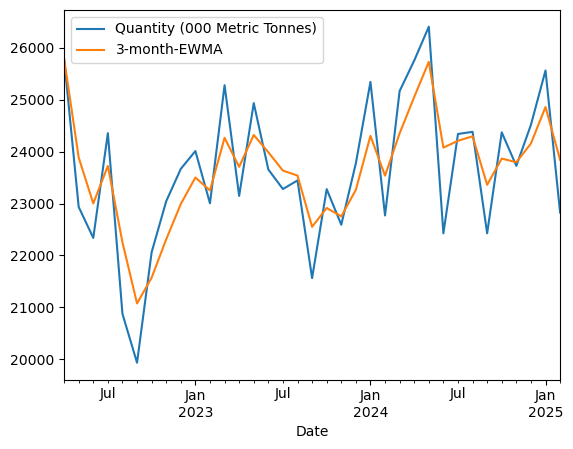

In [43]:
t_import['3-month-EWMA']=t_import['Quantity (000 Metric Tonnes)'].ewm(span=3).mean()
t_import[['Quantity (000 Metric Tonnes)','3-month-EWMA']].plot()

<AxesSubplot:>

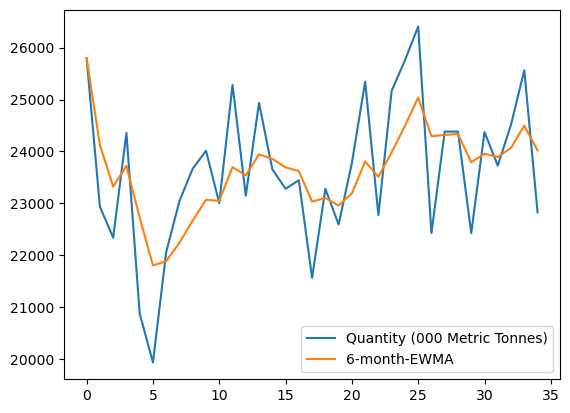

In [27]:
t_import['6-month-EWMA']=t_import['Quantity (000 Metric Tonnes)'].ewm(span=6).mean()
t_import[['Quantity (000 Metric Tonnes)','6-month-EWMA']].plot()

In [55]:
import numpy as np
data = t_import['Quantity (000 Metric Tonnes)']

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# EWMA of 3-month
span = 3
ewma_model = train.ewm(span=span).mean()


forecast = ewma_model.iloc[-1] 
ewma_forecast = [forecast] * len(test) 

# Model Evaluation
mae = mean_absolute_error(test, ewma_forecast)
rmse = np.sqrt(mean_squared_error(test, ewma_forecast))
mape = np.mean(np.abs((test - ewma_forecast) / test)) * 100  
accuracy = 100 - mape  

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 806.55
Root Mean Squared Error (RMSE): 1021.90
Mean Absolute Percentage Error (MAPE): 3.42%
Forecast Accuracy: 96.58%


In [50]:
# 6 month EWMA 
data = t_import['Quantity (000 Metric Tonnes)']

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]


span = 6 
ewma_model = train.ewm(span=span).mean()


forecast = ewma_model.iloc[-1] 
ewma_forecast = [forecast] * len(test)  

# Model Evaluation
mae = mean_absolute_error(test, ewma_forecast)
rmse = np.sqrt(mean_squared_error(test, ewma_forecast))
mape = np.mean(np.abs((test - ewma_forecast) / test)) * 100 
accuracy = 100 - mape  

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 792.81
Root Mean Squared Error (RMSE): 1048.30
Mean Absolute Percentage Error (MAPE): 3.38%
Forecast Accuracy: 96.62%


### EWMA for NET Exports data

<AxesSubplot:xlabel='Date'>

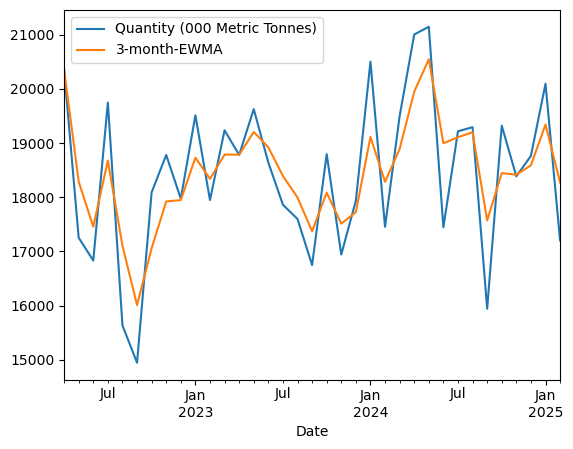

In [63]:
net_export['3-month-EWMA']=net_export['Quantity (000 Metric Tonnes)'].ewm(span=3).mean()
net_export[['Quantity (000 Metric Tonnes)','3-month-EWMA']].plot()

In [67]:
data = net_export['Quantity (000 Metric Tonnes)']

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

span = 3
ewma_model = train.ewm(span=span).mean()

forecast = ewma_model.iloc[-1]  
ewma_forecast = [forecast] * len(test)  

# Model Evaluation
mae = mean_absolute_error(test, ewma_forecast)
rmse = np.sqrt(mean_squared_error(test, ewma_forecast))
mape = np.mean(np.abs((test - ewma_forecast) / test)) * 100  
acc = 100-mape

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Forecast Accuracy: {acc:.2f}%")

Mean Absolute Error (MAE): 1074.75
Root Mean Squared Error (RMSE): 1480.47
Mean Absolute Percentage Error (MAPE): 6.24%
Forecast Accuracy: 93.76%


In [68]:
# EWMA - 4month 
data = net_export['Quantity (000 Metric Tonnes)']

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]


span = 4# Adjust span as needed
ewma_model = train.ewm(span=span).mean()
forecast = ewma_model.iloc[-1]  
ewma_forecast = [forecast] * len(test)  

# Model Evaluation
mae = mean_absolute_error(test, ewma_forecast)
rmse = np.sqrt(mean_squared_error(test, ewma_forecast))
mape = np.mean(np.abs((test - ewma_forecast) / test)) * 100 
accuracy = 100 - mape

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 1083.31
Root Mean Squared Error (RMSE): 1508.85
Mean Absolute Percentage Error (MAPE): 6.30%
Forecast Accuracy: 93.70%


In [59]:
# EWMA - 6month span
data = net_export['Quantity (000 Metric Tonnes)']

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

span = 6
ewma_model = train.ewm(span=span).mean()

forecast = ewma_model.iloc[-1]  
ewma_forecast = [forecast] * len(test) 

# Model Evaluation
mae = mean_absolute_error(test, ewma_forecast)
rmse = np.sqrt(mean_squared_error(test, ewma_forecast))
mape = np.mean(np.abs((test - ewma_forecast) / test)) * 100  
accuracy = 100 - mape  

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

Mean Absolute Error (MAE): 1202.64
Root Mean Squared Error (RMSE): 1578.57
Mean Absolute Percentage Error (MAPE): 7.07%
Forecast Accuracy: 92.93%


## ETS Decomposition and Forecasting 

### Decomposition 

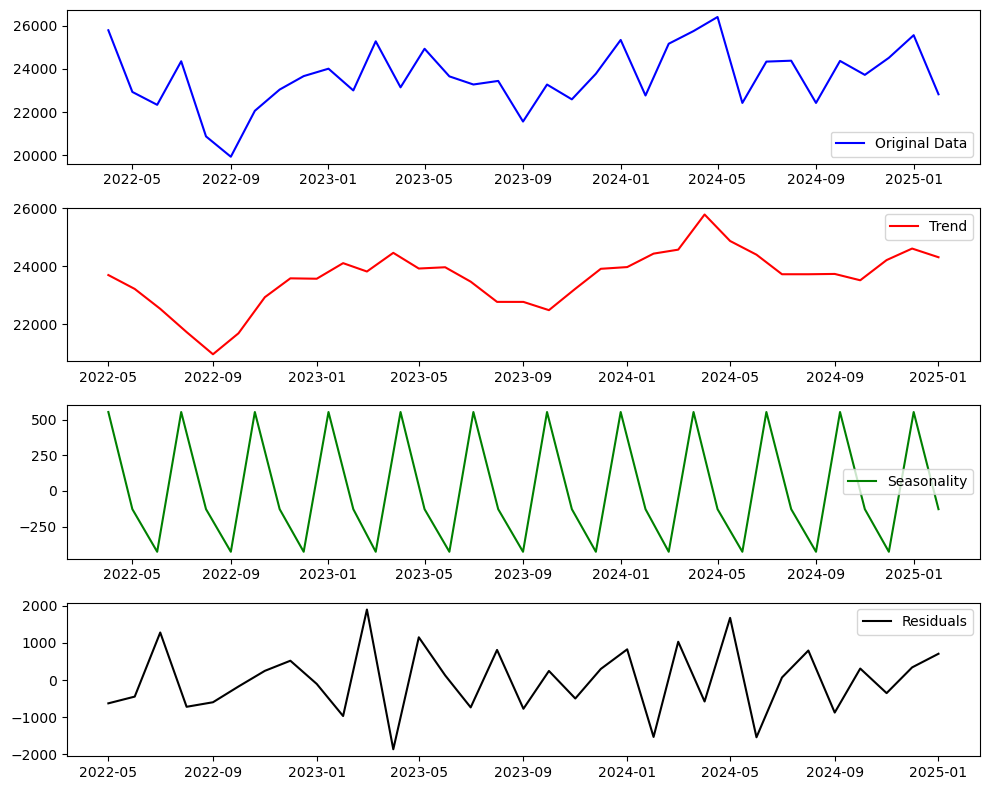

In [71]:
# for 3 months
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(t_import['Quantity (000 Metric Tonnes)'], model='additive', period=3)  

# plotting the decomposed components
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(result.observed, label='Original Data', color='blue')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='red')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality', color='green')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Residuals', color='black')
plt.legend()

plt.tight_layout()
plt.show()

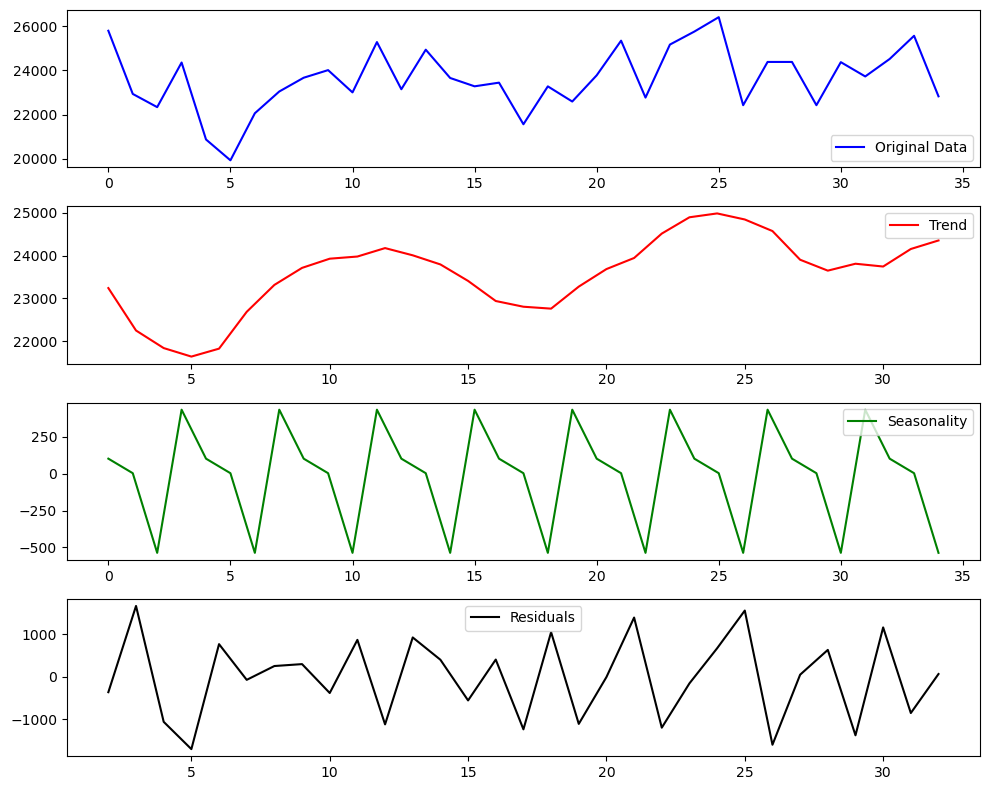

In [28]:
# for 6 months
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(t_import['Quantity (000 Metric Tonnes)'], model='additive', period=4)  

plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(result.observed, label='Original Data', color='blue')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='red')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality', color='green')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Residuals', color='black')
plt.legend()

plt.tight_layout()
plt.show()

Let's Analyse Which ETS is better 

In [73]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error
def analyze_ets(data, period):
    decomposition = sm.tsa.seasonal_decompose(data, model='additive', period=period)

    trend_var = np.var(decomposition.trend.dropna())  # Variance of trend
    seasonal_var = np.var(decomposition.seasonal.dropna())  # Variance of seasonality
    residual_var = np.var(decomposition.resid.dropna())  # Variance of residuals
    
    # Compute MAPE for residuals (removing NaN values)
    actual = data.loc[decomposition.resid.dropna().index]
    residuals = decomposition.resid.dropna()
    mape_residuals = mean_absolute_percentage_error(actual, actual - residuals)

    return {
        "Trend Variance": trend_var,
        "Seasonal Variance": seasonal_var,
        "Residual Variance": residual_var,
        "Residual MAPE (%)": mape_residuals * 100
    }

periods = [3, 4, 5, 6]
results = {f"{p}-month": analyze_ets(t_import["Quantity (000 Metric Tonnes)"], p) for p in periods}

ets_comparison_df = pd.DataFrame(results).T
print(ets_comparison_df)

         Trend Variance  Seasonal Variance  Residual Variance  \
3-month   932392.754968      168089.233666      812074.475031   
4-month   761445.755122      118241.751419      923674.878252   
5-month   695437.613471      208771.949195      943799.377065   
6-month   565795.079643      283821.838645      896592.089333   

         Residual MAPE (%)  
3-month           3.161187  
4-month           3.474950  
5-month           3.324659  
6-month           3.492303  


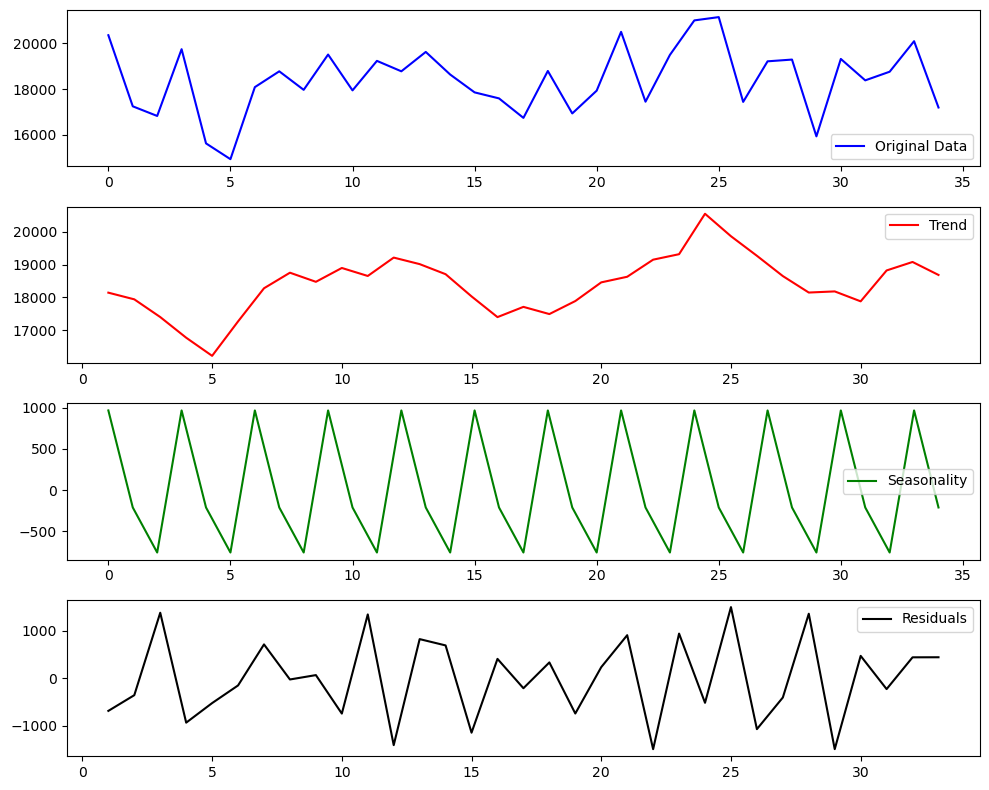

In [29]:
# for 3 months
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(net_export['Quantity (000 Metric Tonnes)'], model='additive', period=3)  

# plotting the decomposed components
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(result.observed, label='Original Data', color='blue')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='red')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality', color='green')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Residuals', color='black')
plt.legend()

plt.tight_layout()
plt.show()

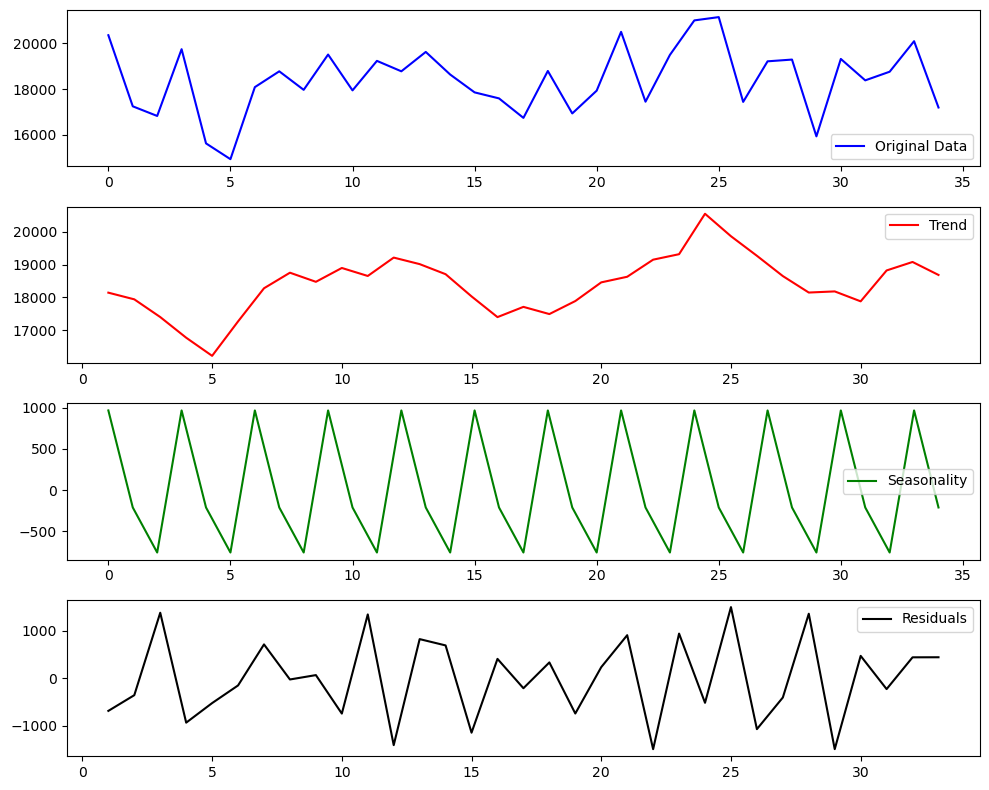

In [30]:
# for 6 months
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(net_export['Quantity (000 Metric Tonnes)'], model='additive', period=3)  

# plotting the decomposed components
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(result.observed, label='Original Data', color='blue')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Trend', color='red')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality', color='green')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Residuals', color='black')
plt.legend()

plt.tight_layout()
plt.show()

# Holt-Winters Exponential Smoothing (ETS) Model.

In [74]:
# Train-Test
train_size = int(len(t_import) * 0.8)  
train, test = t_import.iloc[:train_size], t_import.iloc[train_size:]

model = ExponentialSmoothing(
    train['Quantity (000 Metric Tonnes)'],  
    trend='add',  
    seasonal='add',  
    seasonal_periods= 3  
)
# 3-Month Span
ets_fit = model.fit()
test_predictions = ets_fit.forecast(steps=len(test))
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Quantity (000 Metric Tonnes)'], test_predictions)
rmse = mean_squared_error(test['Quantity (000 Metric Tonnes)'], test_predictions, squared=False)
mape = (abs(test['Quantity (000 Metric Tonnes)'] - test_predictions) / test['Quantity (000 Metric Tonnes)']).mean() * 100

print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

C:\Users\Rahul Raj\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


📌 Mean Absolute Error (MAE): 904.20
📌 Root Mean Squared Error (RMSE): 1195.70
📌 Mean Absolute Percentage Error (MAPE): 3.91%


C:\Users\Rahul Raj\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:915: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [75]:
train_size = int(len(t_import) * 0.8)  
train, test = t_import.iloc[:train_size], t_import.iloc[train_size:]

model = ExponentialSmoothing(
    train['Quantity (000 Metric Tonnes)'],  
    trend='add',  
    seasonal='add',  
    seasonal_periods= 4  
)
# 4-Month Span
ets_fit = model.fit()
test_predictions = ets_fit.forecast(steps=len(test))
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Quantity (000 Metric Tonnes)'], test_predictions)
rmse = mean_squared_error(test['Quantity (000 Metric Tonnes)'], test_predictions, squared=False)
mape = (abs(test['Quantity (000 Metric Tonnes)'] - test_predictions) / test['Quantity (000 Metric Tonnes)']).mean() * 100

print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

C:\Users\Rahul Raj\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


📌 Mean Absolute Error (MAE): 997.89
📌 Root Mean Squared Error (RMSE): 1160.05
📌 Mean Absolute Percentage Error (MAPE): 4.25%


In [60]:
train_size = int(len(t_import) * 0.8)  
train, test = t_import.iloc[:train_size], t_import.iloc[train_size:]

model = ExponentialSmoothing(
    train['Quantity (000 Metric Tonnes)'],  
    trend='add',  
    seasonal='add',  
    seasonal_periods= 6
)
# 6-Month Span
ets_fit = model.fit()
test_predictions = ets_fit.forecast(steps=len(test))
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Quantity (000 Metric Tonnes)'], test_predictions)
rmse = mean_squared_error(test['Quantity (000 Metric Tonnes)'], test_predictions, squared=False)
mape = (abs(test['Quantity (000 Metric Tonnes)'] - test_predictions) / test['Quantity (000 Metric Tonnes)']).mean() * 100

print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

📌 Mean Absolute Error (MAE): 1559.26
📌 Root Mean Squared Error (RMSE): 1890.22
📌 Mean Absolute Percentage Error (MAPE): nan%


In [33]:
train_size = int(len(t_import) * 0.8)  
train, test = t_import.iloc[:train_size], t_import.iloc[train_size:]

model = ExponentialSmoothing(
    train['Quantity (000 Metric Tonnes)'],  
    trend='add',  
    seasonal='add',  
    seasonal_periods= 5
)
# 5-Month Span
ets_fit = model.fit()
test_predictions = ets_fit.forecast(steps=len(test))
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Quantity (000 Metric Tonnes)'], test_predictions)
rmse = mean_squared_error(test['Quantity (000 Metric Tonnes)'], test_predictions, squared=False)
mape = (abs(test['Quantity (000 Metric Tonnes)'] - test_predictions) / test['Quantity (000 Metric Tonnes)']).mean() * 100

print(f"📌 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📌 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

📌 Mean Absolute Error (MAE): 1175.39
📌 Root Mean Squared Error (RMSE): 1386.05
📌 Mean Absolute Percentage Error (MAPE): 5.03%


# SARIMA 

## For Imports 

In [13]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Selecting the relevant column
data = t_import['Quantity (000 Metric Tonnes)'].dropna()

# Stationarity using ADF Test
adf_test = adfuller(data.dropna())
################################

adf_test_results = {
    "ADF Statistic": adf_test[0],
    "p-value": adf_test[1],
    "Critical Values": adf_test[4],
    "Is Stationary": adf_test[1] < 0.05
}
print(adf_test_results)

{'ADF Statistic': -4.79361713776842, 'p-value': 5.593580093449559e-05, 'Critical Values': {'1%': -3.639224104416853, '5%': -2.9512301791166293, '10%': -2.614446989619377}, 'Is Stationary': True}


In [14]:
# Differencing if needed (for stationarity)
if adf_test[1] >= 0.05:
    data_diff = data.diff().dropna()
else:
    data_diff = data

In [15]:
import itertools
import warnings
warnings.filterwarnings("ignore")

# Define the p, d, q range
p_values = range(0, 3)  
d_values = range(0, 2)  
q_values = range(0, 3)  

best_aic = float("inf")
best_order = None
best_model = None

# Iterate over all possible combinations
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = sm.tsa.ARIMA(data, order=(p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
            best_model = results
    except:
        continue

print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")

Best ARIMA order: None with AIC: inf


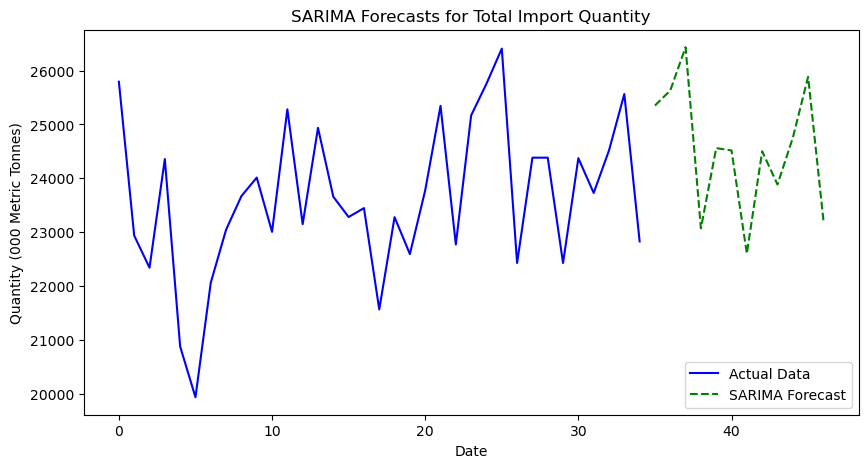

SARIMA RMSE as a percentage: 1.12%


({'ADF Statistic': -4.79361713776842,
  'p-value': 5.593580093449559e-05,
  'Critical Values': {'1%': -3.639224104416853,
   '5%': -2.9512301791166293,
   '10%': -2.614446989619377},
  'Is Stationary': True},
 {'ARIMA AIC': 602.7921688440197,
  'SARIMA AIC': 382.08870549819756,
  'ARIMA RMSE': 1480.0046998379116,
  'SARIMA RMSE': 273.2867591344511})

In [19]:
import numpy as np
# ARIMA 
arima_model = ARIMA(data, order=(1,1,1))  
arima_fit = arima_model.fit()

# SARIMA
sarima_model = SARIMAX(data, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()

# 12 months Forecasting 
arima_forecast = arima_fit.forecast(steps=12)
sarima_forecast = sarima_fit.forecast(steps=12)

# Model evaluation results
arima_rmse = np.sqrt(mean_squared_error(data[-12:], arima_forecast))
sarima_rmse = np.sqrt(mean_squared_error(data[-12:], sarima_forecast))
mean_actual = data[-12:].mean() 
sarima_rmse_percent = (sarima_rmse / mean_actual) * 100
model_evaluation = {
    "ARIMA AIC": arima_fit.aic,
    "SARIMA AIC": sarima_fit.aic,
    "ARIMA RMSE": arima_rmse,
    "SARIMA RMSE": sarima_rmse,
}

#Plot the forecasts
plt.figure(figsize=(10,5))
plt.plot(data, label="Actual Data", color="blue")
plt.plot(sarima_forecast, label="SARIMA Forecast", linestyle="dashed", color="green")
plt.legend()
plt.title("SARIMA Forecasts for Total Import Quantity")
plt.xlabel("Date")
plt.ylabel("Quantity (000 Metric Tonnes)")
plt.show()

print(f"SARIMA RMSE as a percentage: {sarima_rmse_percent:.2f}%")
adf_test_results, model_evaluation

### For Exports

In [21]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Selecting the relevant column
ndata = net_export['Quantity (000 Metric Tonnes)'].dropna()

# Stationarity Check using ADF Test
adf_test = adfuller(ndata.dropna())

adf_test_results = {
    "ADF Statistic": adf_test[0],
    "p-value": adf_test[1],
    "Critical Values": adf_test[4],
    "Is Stationary": adf_test[1] < 0.05  # Stationary if p-value < 0.05
}
print(adf_test_results)

{'ADF Statistic': -5.566197215787516, 'p-value': 1.5028336306754858e-06, 'Critical Values': {'1%': -3.639224104416853, '5%': -2.9512301791166293, '10%': -2.614446989619377}, 'Is Stationary': True}


In [27]:
import itertools
import warnings
warnings.filterwarnings("ignore")


p_values = range(0, 3)  # Try values 0, 1, 2
d_values = range(0, 2)  # Try values 0, 1
q_values = range(0, 3)  # Try values 0, 1, 2

best_aic = float("inf")
best_order = None
best_model = None

# Iterate over all possible combinations
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = sm.tsa.ARIMA(ndata, order=(p, d, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, d, q)
            best_model = results
    except:
        continue

print(f"Best ARIMA order: {best_order} with AIC: {best_aic}")

Best ARIMA order: None with AIC: inf


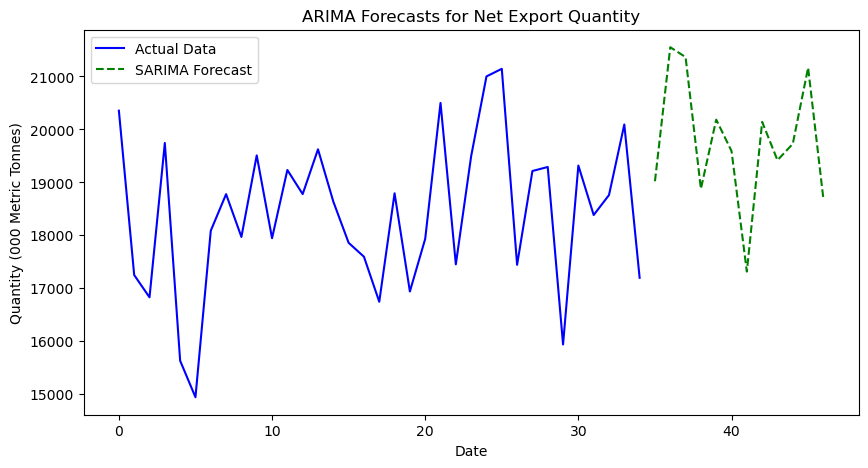

SARIMA RMSE as a percentage: 1.12%


({'ADF Statistic': -5.566197215787516,
  'p-value': 1.5028336306754858e-06,
  'Critical Values': {'1%': -3.639224104416853,
   '5%': -2.9512301791166293,
   '10%': -2.614446989619377},
  'Is Stationary': True},
 {'ARIMA AIC': 608.3566483207917,
  'SARIMA AIC': 392.8334591808356,
  'ARIMA RMSE': 1480.0046998379116,
  'SARIMA RMSE': 273.2867591344511})

In [22]:

arima_model = ARIMA(ndata, order=(1,1,1))  # Assuming one differencing step
arima_fit = arima_model.fit()


sarima_model = SARIMAX(ndata, order=(1,1,2), seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()

# 12 Months Forecasting
arima_forecast_ex = arima_fit.forecast(steps=12)
sarima_forecast_ex = sarima_fit.forecast(steps=12)

# Compute RMSE for both models
arima_rmse = np.sqrt(mean_squared_error(data[-12:], arima_forecast))
sarima_rmse = np.sqrt(mean_squared_error(data[-12:], sarima_forecast))
mean_actual = data[-12:].mean() 
sarima_rmse_percent = (sarima_rmse / mean_actual) * 100

# Model evaluation results
model_evaluation = {
    "ARIMA AIC": arima_fit.aic,
    "SARIMA AIC": sarima_fit.aic,
    "ARIMA RMSE": arima_rmse,
    "SARIMA RMSE": sarima_rmse,
}

# Plot the forecasts
plt.figure(figsize=(10,5))
plt.plot(ndata, label="Actual Data", color="blue")
plt.plot(sarima_forecast_ex, label="SARIMA Forecast", linestyle="dashed", color="green")
plt.legend()
plt.title("ARIMA Forecasts for Net Export Quantity")
plt.xlabel("Date")
plt.ylabel("Quantity (000 Metric Tonnes)")
plt.show()


print(f"SARIMA RMSE as a percentage: {sarima_rmse_percent:.2f}%")
adf_test_results, model_evaluation

# GARCH

In [3]:
pip install numpy==1.21.5

  Using cached numpy-1.21.5-cp39-cp39-win_amd64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Rahul Raj\\anaconda3\\Lib\\site-packages\\~~mpy\\.libs\\libopenblas64__v0.3.21-gcc_10_3_0.dll'
Consider using the `--user` option or check the permissions.



In [4]:
pip install arch

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.6.0 requires daal==2021.4.0, which is not installed.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.24.4 which is incompatible.



  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Using cached numpy-1.24.4-cp39-cp39-win_amd64.whl (14.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Uninstalling numpy-1.21.5:
      Successfully uninstalled numpy-1.21.5


In [39]:
from arch import arch_model
import numpy as np

data = t_import[['Date', 'Quantity (000 Metric Tonnes)']].copy()
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Convert import volume to log-returns to model volatility
data['log_return'] = np.log(data['Quantity (000 Metric Tonnes)']).diff().dropna()


In [40]:
# Stationarity Check using ADF Test
adf_test = adfuller(data['log_return'].dropna())
print(f"ADF Test Statistic: {adf_test[0]:.4f}")
print(f"p-value: {adf_test[1]:.4f}")
if adf_test[1] < 0.05:
    print("Data is stationary (Reject H0)")
else:
    print("Data is non-stationary (Fail to reject H0)")

ADF Test Statistic: -3.8730
p-value: 0.0022
Data is stationary (Reject H0)


In [45]:
# Rescale log returns
data['scaled_log_return'] = data['log_return'] * 100

# Run GARCH
garch_model = arch_model(data['scaled_log_return'].dropna(), vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp="off")

In [52]:
garch_forecast = garch_result.forecast(horizon=12)

# 12 forecasted mean log-returns
forecast_values = garch_forecast.mean.values.flatten()

# Convert log-return forecasts to import volume (exponentiate and scale)
last_value = data['Quantity (000 Metric Tonnes)'].iloc[-1]
forecasted_import_volume = last_value * np.exp(np.cumsum(forecast_values))

print("Forecasted Import Volumes for next 12 months:")
print(forecasted_import_volume)


Forecasted Import Volumes for next 12 months:
[16477.70984536 11894.4636504   8586.03937431  6197.8475284
  4473.92707052  3229.51207505  2331.22893568  1682.80168157
  1214.73333492   876.85738083   632.96103286   456.90402781]


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual_values = data['Quantity (000 Metric Tonnes)'].iloc[-12:].values

# Aligning lengths and calculate metrics
forecasted_values = forecasted_import_volume[:len(actual_values)]  

mae = mean_absolute_error(actual_values, forecasted_values)
rmse = np.sqrt(mean_squared_error(actual_values, forecasted_values))
mape = np.mean(np.abs((actual_values - forecasted_values) / actual_values)) * 100

print(f"📊 GARCH Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")


📊 GARCH Model Evaluation:
Mean Absolute Error (MAE): 19491.33
Root Mean Squared Error (RMSE): 19996.84%


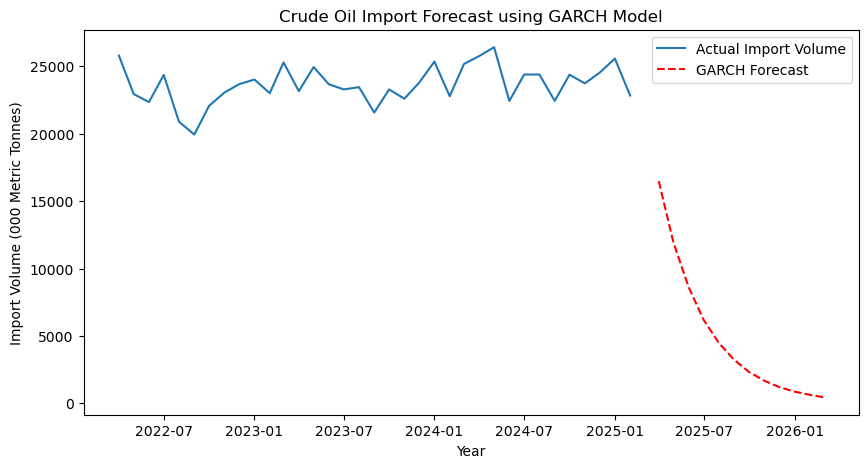

Forecasted Crude Oil Import Volume for Next 12 Months:
[16477.70984536 11894.4636504   8586.03937431  6197.8475284
  4473.92707052  3229.51207505  2331.22893568  1682.80168157
  1214.73333492   876.85738083   632.96103286   456.90402781]


In [53]:
# Plotting the Forecasting 
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Quantity (000 Metric Tonnes)'], label="Actual Import Volume")
plt.plot(pd.date_range(start=data.index[-1], periods=forecast_horizon + 1, freq='M')[1:], 
         forecasted_import_volume, label="GARCH Forecast", linestyle="dashed", color="red")
plt.xlabel("Year")
plt.ylabel("Import Volume (000 Metric Tonnes)")
plt.title("Crude Oil Import Forecast using GARCH Model")
plt.legend()
plt.show()

print("Forecasted Crude Oil Import Volume for Next 12 Months:")
print(forecasted_import_volume)


#### As, We can see GARCH model is a failure. Let's go for Integration with LSTM 

# PART - 2 Deep Learning Integration


## GARCH + LSTM 

In [32]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from arch import arch_model

In [12]:
!pip uninstall numba arch -y
!pip install numba==0.56.4 
!pip install arch

Unable to create process using 'C:\Users\Rahul Raj\anaconda3\python.exe "C:\Users\Rahul Raj\anaconda3\Scripts\pip-script.py" uninstall numba arch -y'
Unable to create process using 'C:\Users\Rahul Raj\anaconda3\python.exe "C:\Users\Rahul Raj\anaconda3\Scripts\pip-script.py" install numba==0.56.4  # Or a compatible version'
Unable to create process using 'C:\Users\Rahul Raj\anaconda3\python.exe "C:\Users\Rahul Raj\anaconda3\Scripts\pip-script.py" install arch'


### Imports

In [33]:

data = t_import[["Date", "Quantity (000 Metric Tonnes)"]].copy()
data = data.sort_values("Date")
data.set_index("Date", inplace=True)

# Normalize the values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_len=3):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 3
X, y = create_sequences(data_scaled, seq_len)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


## LSTM 

In [34]:
model = Sequential()
model.add(LSTM(units=50, input_shape=(seq_len, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=100, verbose=0)

y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)


C:\Users\Rahul Raj\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step


### Fitting LSTM into Residuals of GARCH

In [35]:
# Calculate residuals
residuals = y_test_inv.flatten() - y_pred_inv.flatten()
# Fit GARCH(1,1)
garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp='off')

# Forecast future volatility
garch_forecast = garch_fit.forecast(horizon=5)
print("GARCH Forecast Variance:\n", garch_forecast.variance[-1:])

GARCH Forecast Variance:
             h.1           h.2           h.3           h.4           h.5
6  1.198519e+06  1.206209e+06  1.212024e+06  1.216422e+06  1.219748e+06


C:\Users\Rahul Raj\anaconda3\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.993e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Inverse-transform predicted and true values from LSTM
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

# Print results
print(f"📉 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📈 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📊 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


📉 Mean Absolute Error (MAE): 862.68
📈 Root Mean Squared Error (RMSE): 1011.46
📊 Mean Absolute Percentage Error (MAPE): 3.60%


## CNN + LSTM

In [56]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

In [58]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 6  # 6 months
X, y = create_sequences(data_scaled, window_size)

# Reshape for CNN+LSTM: [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

### Model

In [59]:
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(window_size, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(100, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\Users\Rahul Raj\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 5, 64)               │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 2, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100)                 │          66,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,293 (258.96 KB)

 Trainable params: 66,293 (258.96 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(X, y, epochs=50, batch_size=8, validation_split=0.1)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - loss: 0.2788 - val_loss: 0.2584
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1455 - val_loss: 0.1344
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0907 - val_loss: 0.0548
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0488 - val_loss: 0.0290
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0476 - val_loss: 0.0284
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0508 - val_loss: 0.0287
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0513 - val_loss: 0.0365
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0430 - val_loss: 0.0412
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0434 - val_loss: 0.0417
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0398 - val_loss: 0.0363
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0542 - val_loss: 0.0339
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0394 - val_loss: 0.0344


In [63]:
last_window = data_scaled[-window_size:]
input_seq = last_window.reshape(1, window_size, 1)
pred_scaled = model.predict(input_seq)

# Inverse transform
predicted_quantity = scaler.inverse_transform(pred_scaled)
print(f"Predicted next month's import (in 000 MT): {predicted_quantity[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Predicted next month's import (in 000 MT): 23799.64


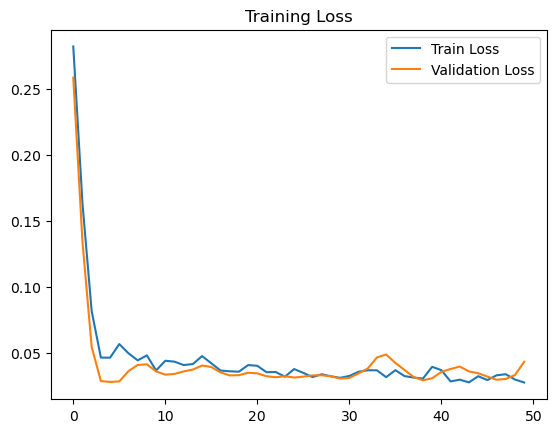

In [64]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

In [65]:
# Define train-test split (e.g., last 6 months as test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [66]:
model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0266 - val_loss: 0.0351
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0306 - val_loss: 0.0336
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0263 - val_loss: 0.0292
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0272 - val_loss: 0.0279
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0302 - val_loss: 0.0294
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0370 - val_loss: 0.0301
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0236 - val_loss: 0.0280
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0249 - val_loss: 0.0283
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0353 - val_loss: 0.0295
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0271 - val_loss: 0.0297
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0280 - val_loss: 0.0290
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0287 - val_loss: 0.0279


In [67]:
y_pred_scaled = model.predict(X_test)

# Inverse scale
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 1181.39
RMSE : 1343.92
MAPE : 4.94%


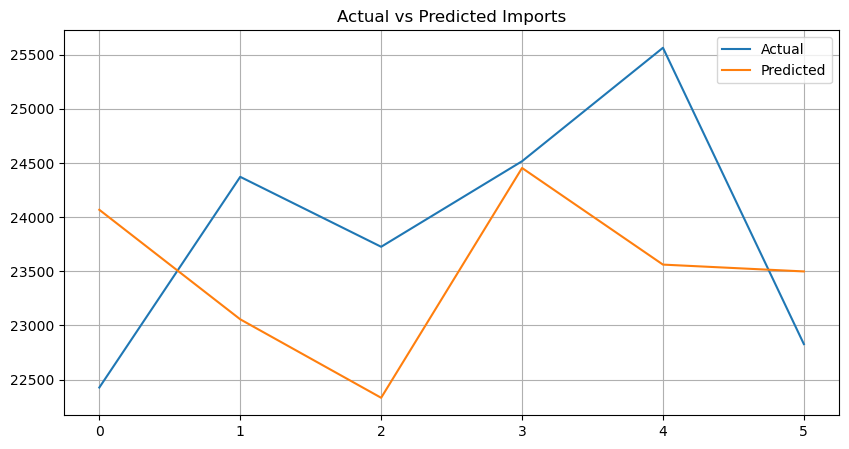

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted Imports")
plt.legend()
plt.grid(True)
plt.show()

# Stochastic Calculus